# TiDE LoRA Fine-tuning — Photodiode data (500/600/700W)

In [1]:
import os
import io
import copy
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from scipy.interpolate import interp1d
from tqdm import tqdm
from peft import LoraConfig, get_peft_model
from TiDE import quantile_loss

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# ── 공통 설정 ──────────────────────────────────────────────────────────────────
CUTOFF_HZ = 2.0
SIM_DT    = 0.0357
WINDOW    = 50
P         = 50

WATT_TO_LP = {"500W": 38, "600W": 91, "700W": 82}   # laser_power_number
WATT_TO_W  = {"500W": 500.0, "600W": 600.0, "700W": 700.0}

def fft_lowpass(sig, dt, cutoff=CUTOFF_HZ):
    n, mean = len(sig), sig.mean()
    F = np.fft.rfft(sig - mean)
    F[np.fft.rfftfreq(n, d=dt) > cutoff] = 0
    return np.fft.irfft(F, n=n) + mean

def resample_to_dt(time_raw, sig_raw, target_dt):
    t_uni = np.arange(time_raw[0], time_raw[-1], target_dt)
    return t_uni, interp1d(time_raw, sig_raw, kind='linear', fill_value='extrapolate')(t_uni)

device: cuda


## 1. Pretrained TiDE 로드 + LoRA wrap

In [2]:
class Safe_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        return super().find_class(module, name)

with open('/home/ftk3187/github/DPC_research/DATAFUSION/lora/TiDE_params_single_track_square_MV_lp_demo_less_cov.pkl', 'rb') as f:
    nominal_params = Safe_Unpickler(f).load()

TiDE_base = nominal_params['model'].cpu()
scaler    = nominal_params  # x_max, x_min, y_max, y_min 포함

x_max = nominal_params['x_max']
x_min = nominal_params['x_min']
y_max = nominal_params['y_max']
y_min = nominal_params['y_min']

def scale_x(x): return -1 + 2 * (x - x_min) / (x_max - x_min)
def scale_y(y): return -1 + 2 * (y - y_min) / (y_max - y_min)
def inv_scale_y(y_s): return (y_s + 1) * 0.5 * (y_max - y_min) + y_min

# LoRA wrap
lora_config = LoraConfig(
    r=4,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=[
        "encoders.0.dense.0", "encoders.0.dense.2", "encoders.0.skip",
        "temporal_decoder.dense.0", "temporal_decoder.dense.2", "temporal_decoder.skip",
    ],
    bias="none",
)
peft_model = get_peft_model(TiDE_base, lora_config).to(device)
peft_model.print_trainable_parameters()

trainable params: 6,344 || all params: 789,874 || trainable%: 0.8032


## 2. Simulation covariate 로드 (loc_Z, dist_X, dist_Y per timestep)

In [3]:
df_sim = pd.read_csv('merged_df_2_99_temp_depth.csv').dropna()

# 각 파워별로 loc_Z, dist_X, dist_Y, time_index 저장
sim_cov = {}   # {watt: {time, loc_Z, dist_X, dist_Y}}
for watt, lp in WATT_TO_LP.items():
    df_lp = df_sim[df_sim['laser_power_number'] == lp].reset_index(drop=True)
    sim_cov[watt] = {
        'time':  df_lp['time_index'].values,
        'loc_Z': df_lp['Z'].values,
        'dist_X': df_lp['Dist_to_nearest_X'].values,
        'dist_Y': df_lp['Dist_to_nearest_Y'].values,
    }
    print(f"{watt}: {len(df_lp)} sim steps, time [{df_lp['time_index'].min():.2f}, {df_lp['time_index'].max():.2f}]")

500W: 6292 sim steps, time [0.04, 224.88]
600W: 6293 sim steps, time [0.00, 224.88]
700W: 6293 sim steps, time [0.00, 224.88]


## 3. Photodiode 로드 + 전처리 + covariate 매핑

In [4]:
PD_DIR = Path("/home/ftk3187/github/DPC_research/DATAFUSION/data_0422_photodiode")
PD_FILES = {
    "500W": ["HAMMER_Square_500W_1_7_NO DELAY.csv",  "HAMMER_Square_500W_2_9_NO DELAY.csv"],
    "600W": ["HAMMER_Square_600W_1_12_NO DELAY.csv", "HAMMER_Square_600W_1_13_NO DELAY.csv"],
    "700W": ["HAMMER_Square_700W_1_10_NO DELAY.csv", "HAMMER_Square_700W_2_11_NO DELAY.csv"],
}

all_y = []
all_x = []

for watt, fnames in PD_FILES.items():
    laser_power_val = WATT_TO_W[watt]
    cov = sim_cov[watt]

    for fname in fnames:
        df_pd = pd.read_csv(PD_DIR / fname)
        df_pd.columns = df_pd.columns.str.strip()
        time_raw = df_pd.iloc[:, 0].values - 5
        temp_raw = df_pd.iloc[:, 3].values

        # trim
        first_valid = max(0,              np.argmax(temp_raw >= 1120))
        last_valid  = min(len(temp_raw)-1, len(temp_raw)-1 - np.argmax(temp_raw[::-1] >= 1120))
        time_trim = time_raw[first_valid : last_valid + 1]
        temp_trim = temp_raw[first_valid : last_valid + 1]

        # FFT lowpass → resample to SIM_DT
        dt_orig       = np.median(np.diff(time_trim))
        temp_f        = fft_lowpass(temp_trim, dt_orig)
        t_rs, temp_rs = resample_to_dt(time_trim, temp_f, SIM_DT)

        # covariate interp
        t_clip    = np.clip(t_rs, cov['time'].min(), cov['time'].max())
        loc_Z_rs  = interp1d(cov['time'], cov['loc_Z'],  kind='linear')(t_clip)
        dist_X_rs = interp1d(cov['time'], cov['dist_X'], kind='linear')(t_clip)
        dist_Y_rs = interp1d(cov['time'], cov['dist_Y'], kind='linear')(t_clip)
        laser_rs  = np.full_like(t_rs, laser_power_val)

        x_raw = np.stack([loc_Z_rs, dist_X_rs, dist_Y_rs, laser_rs], axis=1)

        # °C → simulation 스케일 변환 후 scale_y
        temp_sim_scale = (temp_rs + 273.15) * 2
        y_scaled = scale_y(temp_sim_scale.reshape(-1, 1)).flatten()
        x_scaled = scale_x(x_raw)

        all_y.append(y_scaled)
        all_x.append(x_scaled)
        print(f"{watt} {fname}: {len(t_rs)} steps after resample")

print(f"\n총 {len(all_y)}개 시계열 로드 완료")

500W HAMMER_Square_500W_1_7_NO DELAY.csv: 6712 steps after resample
500W HAMMER_Square_500W_2_9_NO DELAY.csv: 6588 steps after resample
600W HAMMER_Square_600W_1_12_NO DELAY.csv: 6853 steps after resample
600W HAMMER_Square_600W_1_13_NO DELAY.csv: 6672 steps after resample
700W HAMMER_Square_700W_1_10_NO DELAY.csv: 6803 steps after resample
700W HAMMER_Square_700W_2_11_NO DELAY.csv: 6881 steps after resample

총 6개 시계열 로드 완료


## 4. Window slicing → TiDE 입력 형태로 변환

In [5]:
STABLE_START = 100   # 앞 스파이크 제거
STABLE_END   = 6300  # 뒤 스파이크 제거

train_past_list, train_future_list, train_target_list = [], [], []
val_past_list,   val_future_list,   val_target_list   = [], [], []

for file_idx, (y_seq, x_seq) in enumerate(zip(all_y, all_x)):
    # 안정 구간만 사용
    y_seq = y_seq[STABLE_START:STABLE_END]
    x_seq = x_seq[STABLE_START:STABLE_END]
    N = len(y_seq)

    segs = []
    for i in range(WINDOW, N - P):
        y_past = y_seq[i-WINDOW:i].reshape(-1, 1)
        x_past = x_seq[i-WINDOW:i]
        x_fut  = x_seq[i:i+P]
        y_tgt  = y_seq[i:i+P].reshape(-1, 1)
        past   = np.concatenate([y_past, x_past], axis=1)
        segs.append((past, x_fut, y_tgt))

    if file_idx % 2 == 0:
        for past, fut, tgt in segs:
            train_past_list.append(past)
            train_future_list.append(fut)
            train_target_list.append(tgt)
    else:
        for past, fut, tgt in segs:
            val_past_list.append(past)
            val_future_list.append(fut)
            val_target_list.append(tgt)

train_past   = torch.tensor(np.array(train_past_list),   dtype=torch.float32).to(device)
train_future = torch.tensor(np.array(train_future_list), dtype=torch.float32).to(device)
train_target = torch.tensor(np.array(train_target_list), dtype=torch.float32).to(device)
val_past     = torch.tensor(np.array(val_past_list),     dtype=torch.float32).to(device)
val_future   = torch.tensor(np.array(val_future_list),   dtype=torch.float32).to(device)
val_target   = torch.tensor(np.array(val_target_list),   dtype=torch.float32).to(device)

print(f"train: {train_past.shape[0]}, val: {val_past.shape[0]}")

train: 18300, val: 18300


## 5. LoRA Fine-tuning

In [6]:
with open('/home/ftk3187/github/DPC_research/DATAFUSION/lora/TiDE_params_single_track_square_MV_lp_demo_less_cov.pkl', 'rb') as f:
    nom = Safe_Unpickler(f).load()

TiDE_base_clean = nom['model'].cpu()
peft_model = get_peft_model(TiDE_base_clean, lora_config).to(device)
peft_model.print_trainable_parameters()

train_dataset = TensorDataset(train_past, train_future, train_target)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

optimizer = torch.optim.Adam(peft_model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
quantiles = [0.05, 0.5, 0.95]
num_epoch = 50

best_val_loss = float('inf')
best_state    = None
save_train_loss = []
save_val_loss   = []

Val_in = [val_past, val_future, None]

for epoch in range(num_epoch):
    peft_model.train()
    for bp, bf, bt in train_loader:
        optimizer.zero_grad()
        out  = peft_model([bp, bf, None])
        loss = quantile_loss(out, bt, quantiles)
        loss.backward()
        optimizer.step()

    peft_model.eval()
    with torch.no_grad():
        val_out  = peft_model(Val_in)
        val_loss = quantile_loss(val_out, val_target, quantiles)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = copy.deepcopy(peft_model.state_dict())

    save_train_loss.append(loss.item())
    save_val_loss.append(val_loss.item())
    scheduler.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | train={loss.item():.4f} | val={val_loss.item():.4f}")

peft_model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

trainable params: 6,344 || all params: 789,874 || trainable%: 0.8032
Epoch   0 | train=0.0209 | val=0.0181
Epoch   5 | train=0.0124 | val=0.0149
Epoch  10 | train=0.0107 | val=0.0143
Epoch  15 | train=0.0142 | val=0.0141
Epoch  20 | train=0.0124 | val=0.0142
Epoch  25 | train=0.0149 | val=0.0139
Epoch  30 | train=0.0158 | val=0.0140
Epoch  35 | train=0.0132 | val=0.0139
Epoch  40 | train=0.0154 | val=0.0139
Epoch  45 | train=0.0151 | val=0.0138

Best val loss: 0.0138


In [7]:
# ── Diagonal GGN Hessian 계산 (Laplace approximation) ──────────────────────
peft_model.eval()

# LoRA 파라미터만 추출
lora_params = [p for p in peft_model.parameters() if p.requires_grad]
n_params = sum(p.numel() for p in lora_params)
print(f"LoRA 파라미터 수: {n_params}")

hessian_diag = torch.zeros(n_params, device=device)

for bp, bf, bt in train_loader:
    out  = peft_model([bp, bf, None])
    # median만 사용
    pred = out[:, :, 0, 1]   # (batch, P)
    target = bt[:, :, 0]      # (batch, P)
    
    loss = ((pred - target) ** 2).sum()
    
    grads = torch.autograd.grad(loss, lora_params, create_graph=False)
    
    idx = 0
    for g in grads:
        n = g.numel()
        hessian_diag[idx:idx+n] += (g.flatten() ** 2)
        idx += n

# normalize by dataset size
hessian_diag /= len(train_loader.dataset)

# prior precision (regularization)
prior_precision = 1.0
posterior_var = 1.0 / (hessian_diag + prior_precision)

print(f"Hessian diag: min={hessian_diag.min():.6f}, max={hessian_diag.max():.6f}")
print(f"Posterior var: min={posterior_var.min():.6f}, max={posterior_var.max():.6f}")
print("Hessian 계산 완료")

LoRA 파라미터 수: 6344
Hessian diag: min=0.000000, max=62.086040
Posterior var: min=0.015851, max=1.000000
Hessian 계산 완료


In [8]:
def predict_with_uncertainty(past_ten, fut_ten, n_samples=100):
    """LoRA 파라미터 분포에서 샘플링해서 uncertainty 추정"""
    lora_params = [p for p in peft_model.parameters() if p.requires_grad]
    
    # 원래 가중치 저장
    original_weights = [p.data.clone() for p in lora_params]
    
    preds = []
    for _ in range(n_samples):
        # posterior에서 샘플링
        idx = 0
        for p, w_orig in zip(lora_params, original_weights):
            n = p.numel()
            std = posterior_var[idx:idx+n].sqrt()
            noise = torch.randn_like(p.data.flatten()) * std
            p.data = w_orig + noise.reshape(p.shape)
            idx += n
        
        with torch.no_grad():
            out = peft_model([past_ten, fut_ten, None])
            preds.append(out[:, :, 0, 1].cpu().numpy())
    
    # 원래 가중치 복원
    for p, w_orig in zip(lora_params, original_weights):
        p.data = w_orig
    
    preds = np.array(preds)  # (n_samples, batch, P)
    mean = preds.mean(axis=0)
    std  = preds.std(axis=0)
    return mean, std

print("predict_with_uncertainty 준비 완료")

predict_with_uncertainty 준비 완료


## 6. Loss 플롯 + 저장

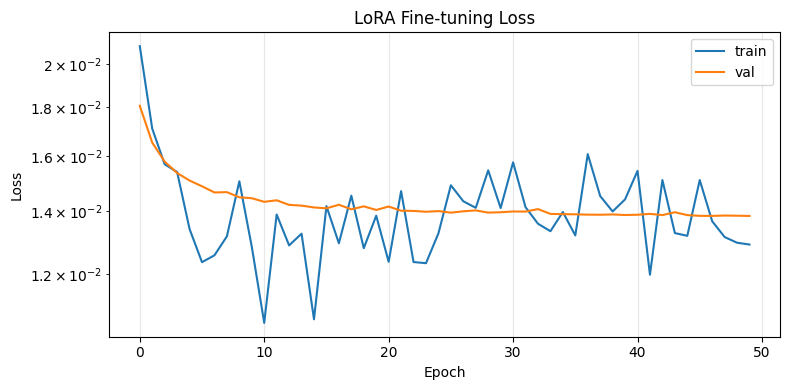

LoRA adapter saved to 'TiDE_lora_photodiode/'


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.semilogy(save_train_loss, label='train')
plt.semilogy(save_val_loss,   label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LoRA Fine-tuning Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# LoRA adapter 저장
peft_model.save_pretrained('TiDE_lora_photodiode')
print("LoRA adapter saved to 'TiDE_lora_photodiode/'")

In [10]:
# LoRA 없는 원본 TiDE로 val loss 확인
TiDE_base.eval().to(device)
with torch.no_grad():
    val_out_base = TiDE_base([val_past, val_future, None])
    val_loss_base = quantile_loss(val_out_base, val_target, quantiles)
print(f"Base TiDE val loss (no LoRA): {val_loss_base:.4f}")

Base TiDE val loss (no LoRA): 0.0414


TiDE_fresh 로드 완료


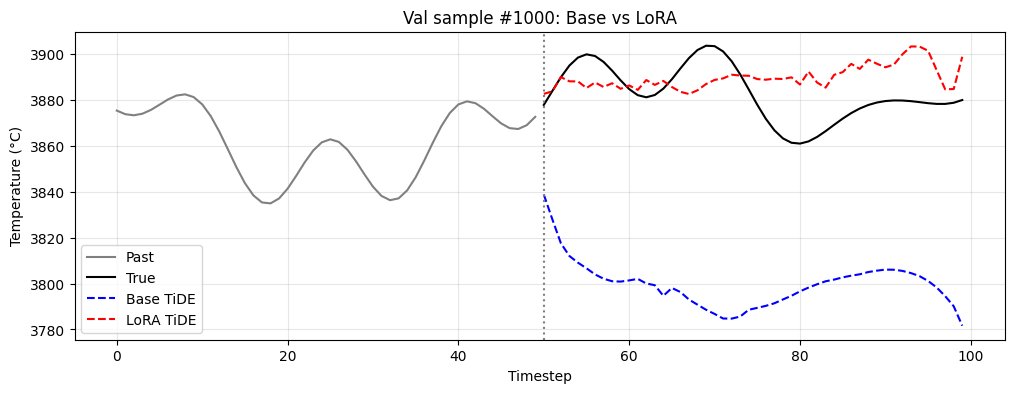

In [11]:
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt

with open('/home/ftk3187/github/DPC_research/DATAFUSION/lora/TiDE_params_single_track_square_MV_lp_demo_less_cov.pkl', 'rb') as f:
    nominal_params_fresh = Safe_Unpickler(f).load()

TiDE_fresh = nominal_params_fresh['model'].to(device)
TiDE_fresh.eval()
print("TiDE_fresh 로드 완료")
# 아무 샘플이나 하나 골라서 base vs LoRA 비교
item = 1000

x_past_item   = val_past[item].unsqueeze(0)
x_future_item = val_future[item].unsqueeze(0)
y_true_item   = val_target[item].unsqueeze(0)

# Base TiDE 예측
with torch.no_grad():
    y_base = TiDE_fresh([x_past_item, x_future_item, None])


# LoRA TiDE 예측
peft_model.eval()
with torch.no_grad():
    y_lora = peft_model([x_past_item, x_future_item, None])

# inverse scale
def inv_y(t):
    return (t + 1) * 0.5 * (y_max - y_min) + y_min

past_plot  = inv_y(x_past_item[0, :, 0].cpu().numpy()).flatten()
true_plot  = inv_y(y_true_item[0, :, 0].cpu().numpy()).flatten()
base_plot  = inv_y(y_base[0, :, 0, 1].detach().cpu().numpy()).flatten()
lora_plot  = inv_y(y_lora[0, :, 0, 1].detach().cpu().numpy()).flatten()

plt.figure(figsize=(12, 4))
plt.plot(range(WINDOW), past_plot, color='gray', label='Past')
plt.plot(range(WINDOW, WINDOW+P), true_plot, color='black', label='True')
plt.plot(range(WINDOW, WINDOW+P), base_plot, color='blue',  linestyle='--', label='Base TiDE')
plt.plot(range(WINDOW, WINDOW+P), lora_plot, color='red',   linestyle='--', label='LoRA TiDE')
plt.axvline(WINDOW, color='gray', linestyle=':')
plt.xlabel('Timestep')
plt.ylabel('Temperature (°C)')
plt.title(f'Val sample #{item}: Base vs LoRA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
def sMAPE(y_true, y_hat):
    return 100 * np.mean(np.abs((y_true - y_hat) / (np.abs(y_true) + np.abs(y_hat))))

def SSE_compute(y_true, y_hat):
    return np.sum((y_true - y_hat)**2)

MAPE_base = np.empty(val_past.shape[0])
MAPE_lora = np.empty(val_past.shape[0])
SSE_base  = 0
SSE_lora  = 0

TiDE_fresh.eval()
peft_model.eval()

for item in range(val_past.shape[0]):
    x_past    = val_past[item,:,:].unsqueeze(0)
    x_future  = val_future[item,:,:].unsqueeze(0)
    y_val     = val_target[item,:,:].unsqueeze(0)

    with torch.no_grad():
        y_hat_base = TiDE_fresh([x_past, x_future, None])
        y_hat_lora = peft_model([x_past, x_future, None])

    y_true_np = y_val.cpu()[:,:,0].squeeze().numpy()
    base_np   = y_hat_base[:,:,0,1].squeeze().detach().cpu().numpy()
    lora_np   = y_hat_lora[:,:,0,1].squeeze().detach().cpu().numpy()

    MAPE_base[item] = sMAPE(y_true_np, base_np)
    MAPE_lora[item] = sMAPE(y_true_np, lora_np)
    SSE_base += SSE_compute(y_true_np, base_np)
    SSE_lora += SSE_compute(y_true_np, lora_np)

n_item  = val_past.shape[0] * val_past.shape[1]
y_s_var = np.var(val_target[:,  :, 0].cpu().numpy())   # scaled 공간 — 원본과 동일 기준

RRMSE_base = np.sqrt(SSE_base / n_item / y_s_var) * 100
RRMSE_lora = np.sqrt(SSE_lora / n_item / y_s_var) * 100

print(f"{'':20} {'Base TiDE':>12} {'LoRA TiDE':>12}")
print(f"{'sMAPE (%)':20} {np.mean(MAPE_base):>12.2f} {np.mean(MAPE_lora):>12.2f}")
print(f"{'RRMSE':20} {RRMSE_base:>12.2f} {RRMSE_lora:>12.2f}")

                        Base TiDE    LoRA TiDE
sMAPE (%)                    3.38         1.13
RRMSE                      174.98        43.14


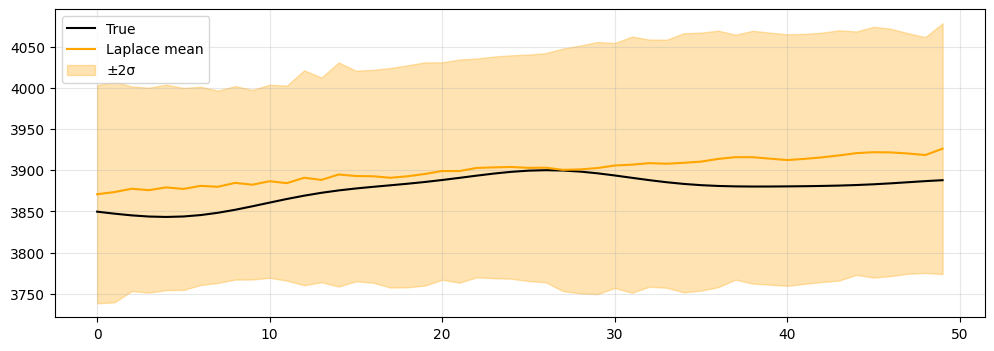

std range: 57.54 ~ 78.65 °C
std range: 57.54 ~ 78.65 °C
mean range: 3870.89 ~ 3926.22 °C
true range: 3843.32 ~ 3900.10 °C
mean range (°C): 1662.30 ~ 1689.96
true range (°C): 1648.51 ~ 1676.90
std range (°C):  28.77 ~ 39.33


In [13]:
prior_precision = 100000.0
posterior_var   = 1.0 / (hessian_diag + prior_precision)

item = 2000
pred_mean_s, pred_std_s = predict_with_uncertainty(
    val_past[item].unsqueeze(0),
    val_future[item].unsqueeze(0),
    n_samples=200
)
pred_mean_np   = pred_mean_s[0]
pred_std_np    = pred_std_s[0]
pred_mean_orig = inv_y(pred_mean_np).flatten()
pred_std_orig  = pred_std_np * (y_max - y_min).flatten() * 0.5
true_plot      = inv_y(val_target[item, :, 0].cpu().numpy()).flatten()

%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(range(P), true_plot, color='black', label='True')
plt.plot(range(P), pred_mean_orig, color='orange', label='Laplace mean')
plt.fill_between(range(P),
                 pred_mean_orig - 2*pred_std_orig,
                 pred_mean_orig + 2*pred_std_orig,
                 color='orange', alpha=0.3, label='±2σ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"std range: {pred_std_orig.min():.2f} ~ {pred_std_orig.max():.2f} °C")

print(f"std range: {pred_std_orig.min():.2f} ~ {pred_std_orig.max():.2f} °C")
print(f"mean range: {pred_mean_orig.min():.2f} ~ {pred_mean_orig.max():.2f} °C")
print(f"true range: {true_plot.min():.2f} ~ {true_plot.max():.2f} °C")

# simulation scale → °C 변환
def sim_to_celsius(t):
    return t / 2 - 273.15

print(f"mean range (°C): {sim_to_celsius(pred_mean_orig.min()):.2f} ~ {sim_to_celsius(pred_mean_orig.max()):.2f}")
print(f"true range (°C): {sim_to_celsius(true_plot.min()):.2f} ~ {sim_to_celsius(true_plot.max()):.2f}")
print(f"std range (°C):  {(pred_std_orig / 2).min():.2f} ~ {(pred_std_orig / 2).max():.2f}")

In [14]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import torch

def inv_y(t):
    return (t + 1) * 0.5 * (y_max - y_min) + y_min

def sim_to_celsius(t):
    return t / 2 - 273.15

# ── Diagonal Hessian 계산 ─────────────────────────────────────────────────────
peft_model.eval()
lora_params = [p for p in peft_model.parameters() if p.requires_grad]
n_params    = sum(p.numel() for p in lora_params)
print(f"LoRA 파라미터 수: {n_params}")

hessian_diag = torch.zeros(n_params, device=device)

for bp, bf, bt in train_loader:
    out    = peft_model([bp, bf, None])
    pred   = out[:, :, 0, 1]
    target = bt[:, :, 0]
    loss   = ((pred - target) ** 2).sum()
    grads  = torch.autograd.grad(loss, lora_params, create_graph=False)

    idx = 0
    for g in grads:
        n = g.numel()
        hessian_diag[idx:idx+n] += g.flatten() ** 2
        idx += n

hessian_diag /= len(train_loader.dataset)
prior_precision = 100000.0
posterior_var   = 1.0 / (hessian_diag + prior_precision)
print(f"Hessian diag: min={hessian_diag.min():.6f}, max={hessian_diag.max():.6f}")
print("Hessian 계산 완료")

def predict_with_uncertainty(past_ten, fut_ten, n_samples=50):
    lora_params      = [p for p in peft_model.parameters() if p.requires_grad]
    original_weights = [p.data.clone() for p in lora_params]

    preds = []
    for _ in range(n_samples):
        idx = 0
        for p, w_orig in zip(lora_params, original_weights):
            n   = p.numel()
            std = posterior_var[idx:idx+n].sqrt()
            noise = torch.randn_like(p.data.flatten()) * std
            p.data = w_orig + noise.reshape(p.shape)
            idx += n

        with torch.no_grad():
            out = peft_model([past_ten, fut_ten, None])
            preds.append(out[:, :, 0, 1].cpu().numpy())

    for p, w_orig in zip(lora_params, original_weights):
        p.data = w_orig

    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

print("predict_with_uncertainty 준비 완료")

LoRA 파라미터 수: 6344
Hessian diag: min=0.000000, max=64.677010
Hessian 계산 완료
predict_with_uncertainty 준비 완료


In [15]:
SEQ_INFO = [
    (0, '500W_Run1'),
    (1, '500W_Run2'),
    (2, '600W_Run1'),
    (3, '600W_Run2'),
    (4, '700W_Run1'),
    (5, '700W_Run2'),
]

START = 100
STEP  = 10

peft_model.eval()
TiDE_fresh.eval()

for SEQ_IDX, WATT_LABEL in SEQ_INFO:
    print(f"\n{'='*40}")
    print(f"{WATT_LABEL} 처리 중...")

    y_seq = all_y[SEQ_IDX]
    x_seq = all_x[SEQ_IDX]
    N     = len(y_seq)
    END   = min(N - P, int(N * (1 - 0.033)))

    frames    = []
    positions = list(range(START, END, STEP))

    for i in positions:
        if i < WINDOW or i + P > N:
            continue

        y_past = y_seq[i-WINDOW:i].reshape(-1, 1)
        x_past = x_seq[i-WINDOW:i]
        x_fut  = x_seq[i:i+P]
        y_true = y_seq[i:i+P]

        past_t   = np.concatenate([y_past, x_past], axis=1)
        past_ten = torch.tensor(past_t[None], dtype=torch.float32).to(device)
        fut_ten  = torch.tensor(x_fut[None],  dtype=torch.float32).to(device)

        with torch.no_grad():
            y_lora = peft_model([past_ten, fut_ten, None])
            y_base = TiDE_fresh([past_ten, fut_ten, None])

        pred_mean_s, pred_std_s = predict_with_uncertainty(past_ten, fut_ten, n_samples=200)
        pred_mean_np = pred_mean_s[0]
        pred_std_np  = pred_std_s[0]

        pred_mean_orig = sim_to_celsius(inv_y(pred_mean_np).flatten())
        pred_std_orig  = pred_std_np * (y_max - y_min).flatten() * 0.5 / 2

        frames.append({
            'i':    i,
            'past': sim_to_celsius(inv_y(y_past[:, 0]).flatten()),
            'true': sim_to_celsius(inv_y(y_true).flatten()),
            'lora': sim_to_celsius(inv_y(y_lora[0, :, 0, 1].cpu().numpy()).flatten()),
            'base': sim_to_celsius(inv_y(y_base[0, :, 0, 1].cpu().numpy()).flatten()),
            'mean': pred_mean_orig,
            'std':  pred_std_orig,
        })

    print(f"{len(frames)} frames 준비 완료")

    fig, ax = plt.subplots(figsize=(5, 5))

    line_past, = ax.plot([], [], color='gray',   linewidth=1.2, label='Past')
    line_true, = ax.plot([], [], color='black',  linewidth=2.0, label='True')
    line_base, = ax.plot([], [], color='blue',   linewidth=1.2, linestyle='--', alpha=0.7, label='Base TiDE')
    line_lora, = ax.plot([], [], color='red',    linewidth=1.5, linestyle='--', label='LoRA TiDE')
    line_mean, = ax.plot([], [], color='orange', linewidth=1.5, linestyle='-',  label='Laplace mean')

    dummy = np.zeros(P)
    fill  = ax.fill_between(
        range(WINDOW, WINDOW+P), dummy, dummy,
        color='orange', alpha=0.2, label='Laplace ±2σ'
    )

    ax.axvline(x=WINDOW, color='gray', linestyle=':', linewidth=1)
    ax.set_xlim(0, WINDOW + P)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(1500, 2000)

    x_future_range = list(range(WINDOW, WINDOW + P))

    def update(frame):
        global fill
        f   = frames[frame]
        i   = f['i']
        t_s = (i - WINDOW) * SIM_DT
        t_e = (i + P)      * SIM_DT

        line_past.set_data(range(WINDOW),      f['past'])
        line_true.set_data(x_future_range,     f['true'])
        line_base.set_data(x_future_range,     f['base'])
        line_lora.set_data(x_future_range,     f['lora'])
        line_mean.set_data(x_future_range,     f['mean'])

        try:
            fill.remove()
        except ValueError:
            pass
        fill = ax.fill_between(
            x_future_range,
            f['mean'] - 2 * f['std'],
            f['mean'] + 2 * f['std'],
            color='orange', alpha=0.2
        )

        ax.set_title(f"{WATT_LABEL} | step={i} | t={t_s:.1f}~{t_e:.1f}s")
        return line_past, line_true, line_base, line_lora, line_mean, fill

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=100, blit=False
    )

    save_path = f'/home/ftk3187/github/DPC_research/DATAFUSION/lora/tide_lora_UQ_2_{WATT_LABEL}.mp4'
    ani.save(save_path, writer=animation.FFMpegWriter(fps=10))
    plt.close()
    print(f"저장 완료: {save_path}")

print("\n전체 완료!")


500W_Run1 처리 중...
639 frames 준비 완료
저장 완료: /home/ftk3187/github/DPC_research/DATAFUSION/lora/tide_lora_UQ_2_500W_Run1.mp4

500W_Run2 처리 중...
627 frames 준비 완료
저장 완료: /home/ftk3187/github/DPC_research/DATAFUSION/lora/tide_lora_UQ_2_500W_Run2.mp4

600W_Run1 처리 중...
653 frames 준비 완료
저장 완료: /home/ftk3187/github/DPC_research/DATAFUSION/lora/tide_lora_UQ_2_600W_Run1.mp4

600W_Run2 처리 중...
636 frames 준비 완료
저장 완료: /home/ftk3187/github/DPC_research/DATAFUSION/lora/tide_lora_UQ_2_600W_Run2.mp4

700W_Run1 처리 중...
648 frames 준비 완료
저장 완료: /home/ftk3187/github/DPC_research/DATAFUSION/lora/tide_lora_UQ_2_700W_Run1.mp4

700W_Run2 처리 중...
656 frames 준비 완료
저장 완료: /home/ftk3187/github/DPC_research/DATAFUSION/lora/tide_lora_UQ_2_700W_Run2.mp4

전체 완료!


In [ ]:
# ======================================================================
# Sliding Forecast Reconstruction
# ======================================================================

SEQ_INFO = [
    (0, '500W_Run1'),
    (1, '500W_Run2'),
    (2, '600W_Run1'),
    (3, '600W_Run2'),
    (4, '700W_Run1'),
    (5, '700W_Run2'),
]

peft_model.eval()
TiDE_fresh.eval()

STEP = P     # non-overlapping forecast
START = WINDOW

for SEQ_IDX, WATT_LABEL in SEQ_INFO:

    print("\n" + "="*80)
    print(WATT_LABEL)

    # ==================================================================
    # sequence
    # ==================================================================
    y_seq = all_y[SEQ_IDX]
    x_seq = all_x[SEQ_IDX]

    N = len(y_seq)

    END = N - P

    # ==================================================================
    # 저장용
    # ==================================================================
    pred_times = []
    pred_mean_all = []
    pred_std_all  = []

    true_all = []

    # ==================================================================
    # sliding inference
    # ==================================================================
    for i in range(START, END, STEP):

        if i < WINDOW or i + P > N:
            continue

        # --------------------------------------------------------------
        # past
        # --------------------------------------------------------------
        y_past = y_seq[i-WINDOW:i].reshape(-1, 1)

        x_past = x_seq[i-WINDOW:i]

        x_fut = x_seq[i:i+P]

        y_true = y_seq[i:i+P]

        # --------------------------------------------------------------
        # tensor
        # --------------------------------------------------------------
        past_t = np.concatenate([y_past, x_past], axis=1)

        past_ten = torch.tensor(
            past_t[None],
            dtype=torch.float32
        ).to(device)

        fut_ten = torch.tensor(
            x_fut[None],
            dtype=torch.float32
        ).to(device)

        # --------------------------------------------------------------
        # prediction
        # --------------------------------------------------------------
        with torch.no_grad():

            pred_mean_s, pred_std_s = predict_with_uncertainty(
                past_ten,
                fut_ten,
                n_samples=200
            )

        pred_mean_np = pred_mean_s[0]

        pred_std_np = pred_std_s[0]

        # --------------------------------------------------------------
        # inverse transform
        # --------------------------------------------------------------
        pred_mean_orig = sim_to_celsius(
            inv_y(pred_mean_np).flatten()
        )

        pred_std_orig = (
            pred_std_np
            * (y_max - y_min).flatten()
            * 0.5 / 2
        )

        true_orig = sim_to_celsius(
            inv_y(y_true).flatten()
        )

        # --------------------------------------------------------------
        # time axis
        # --------------------------------------------------------------
        t_pred = np.arange(i, i + P) * SIM_DT

        # --------------------------------------------------------------
        # save
        # --------------------------------------------------------------
        pred_times.extend(t_pred)

        pred_mean_all.extend(pred_mean_orig)

        pred_std_all.extend(pred_std_orig)

        true_all.extend(true_orig)

    # ==================================================================
    # numpy
    # ==================================================================
    pred_times = np.array(pred_times)

    pred_mean_all = np.array(pred_mean_all)

    pred_std_all = np.array(pred_std_all)

    true_all = np.array(true_all)

    # ==================================================================
    # Plot
    # ==================================================================
    plt.figure(figsize=(12, 5))

    # --------------------------------------------------------------
    # GT
    # --------------------------------------------------------------
    plt.plot(pred_times,
             true_all,
             color='black',
             linewidth=2,
             label='Experiment')

    # --------------------------------------------------------------
    # prediction
    # --------------------------------------------------------------
    plt.plot(pred_times,
             pred_mean_all,
             color='red',
             linewidth=1.5,
             label='TiDE Prediction')

    # --------------------------------------------------------------
    # uncertainty
    # --------------------------------------------------------------
    plt.fill_between(
        pred_times,
        pred_mean_all - 2 * pred_std_all,
        pred_mean_all + 2 * pred_std_all,
        color='red',
        alpha=0.2,
        label='±2σ'
    )

    # --------------------------------------------------------------
    # formatting
    # --------------------------------------------------------------
    plt.title(f"{WATT_LABEL} Sequential Forecast Reconstruction",
              fontsize=14,
              fontweight='bold')

    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")

    plt.grid(True, alpha=0.3)

    plt.legend()

    plt.tight_layout()

    save_path = (
        f"/home/ftk3187/github/DPC_research/"
        f"DATAFUSION/lora/{WATT_LABEL}_forecast.png"
    )

    plt.savefig(save_path,
                dpi=300,
                bbox_inches='tight')

    print(f"저장 완료: {save_path}")

    plt.close()


500W_Run1
